# PM2.5 Imputation Pipeline (XGBoost)
**Objective:** Backcast missing PM2.5 data (2010-2021) using a model trained on 2022-2025 data.

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Config
INPUT_FILE = 'dataset/merged_data_v4_complete.csv'
OUTPUT_FILE = '../dataset/final_dataset_ready_for_modeling.csv'
TARGET = 'pm25'
RANDOM_STATE = 42

PREDICTORS = [
    'pm10', 'so2', 'co', 'no2', 'o3', 'temperature_2m_mean', 'precipitation_sum', 
    'wind_speed_10m_mean', 'washout_effect', 'is_holiday_nasional', 'is_weekend', 
    'Total_Penduduk', 'month', 'year', 'day_of_week'
]

XGB_PARAMS = {
    'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 
    'subsample': 0.8, 'colsample_bytree': 0.8, 'n_jobs': -1, 'random_state': RANDOM_STATE
}

In [6]:
# Load & Preprocess
print("Loading and preparing data...")
df = pd.read_csv(INPUT_FILE, parse_dates=['tanggal'])

# Create Temporal Features
df['month'] = df['tanggal'].dt.month
df['year'] = df['tanggal'].dt.year
df['day_of_week'] = df['tanggal'].dt.dayofweek

# Fill Missing Predictors (Forward -> Backward -> Median)
for col in PREDICTORS:
    if col in df.columns:
        df[col] = df[col].ffill().bfill().fillna(df[col].median())

print(f"Data shape: {df.shape}. Predictors ready.")

Loading and preparing data...
Data shape: (15412, 48). Predictors ready.


In [7]:
# Train & Impute
print("Training XGBoost model...")
train_mask = df[TARGET].notna()
X_train, y_train = df.loc[train_mask, PREDICTORS], df.loc[train_mask, TARGET]
X_missing = df.loc[~train_mask, PREDICTORS]

model = xgb.XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train)

# Validation Score
y_pred_train = model.predict(X_train)
print(f"Training R2 Score: {r2_score(y_train, y_pred_train):.4f}")

# Impute
if len(X_missing) > 0:
    print(f"Imputing {len(X_missing)} missing values...")
    df.loc[~train_mask, TARGET] = model.predict(X_missing)
else:
    print("No missing values to impute.")

Training XGBoost model...
Training R2 Score: 0.9692
Imputing 8801 missing values...


Saving to ../dataset/final_dataset_ready_for_modeling.csv...


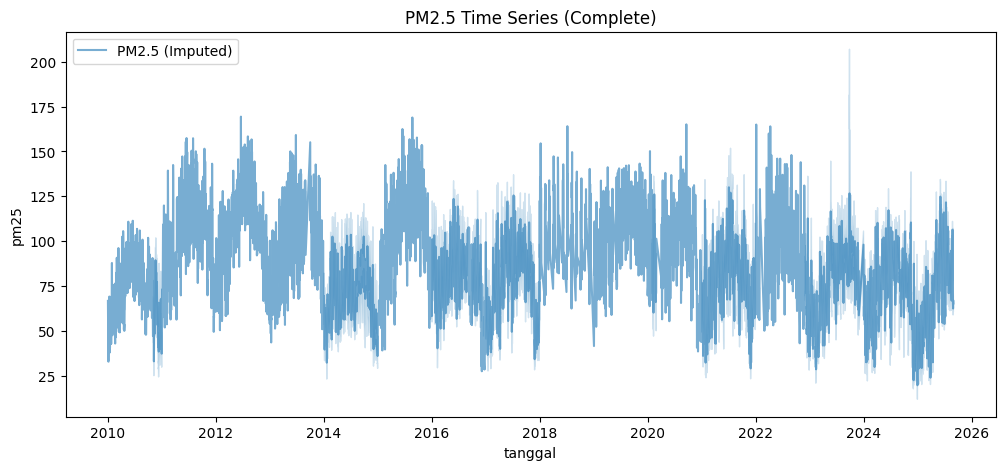

In [8]:
# Save & Plot
print(f"Saving to {OUTPUT_FILE}...")
df.to_csv(OUTPUT_FILE, index=False)

# Simple Visualization for Sanity Check
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='tanggal', y=TARGET, alpha=0.6, label='PM2.5 (Imputed)')
plt.title("PM2.5 Time Series (Complete)")
plt.show()